# RNA-Seq Post-Counted Processing Workflow
### Authors: Emily Skates, Stephen Williams

This pipeline processes STAR + featureCounts outputs through downstream analyses including DESeq2 differential expression, PCA/PERMANOVA clustering, WGCNA co-expression networks, and Gene Ontology/GSEA enrichment.

## 1. Environment Setup & Global Configuration
Initialises required libraries, sets the working directory, and defines global thresholds for gene filtering, plotting, and differential expression cut-offs.

In [1]:
setwd("/Users/steve/Library/CloudStorage/GoogleDrive-stev3.w1l@gmail.com/My Drive/Academia/c_collaborations/emilyS/")

# Conditionally install required packages if not already installed
required_packages <- c("DESeq2", "ggplot2", "ggvenn",
                       "WGCNA", "pheatmap", "vegan",
                       "pairwiseAdonis", "glue", "scales",
                       "gtools", "clusterProfiler", "enrichplot",
                       "org.Mm.eg.db")

# Install required packages if not already installed
new_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]
if (length(new_packages)) {
    install.packages(new_packages)
}

# Load required libraries
suppressPackageStartupMessages({
    library(DESeq2)
    library(ggplot2)
    library(ggvenn)
    library(WGCNA)
    library(pheatmap)
    library(vegan)
    library(pairwiseAdonis)
    library(glue)
    library(scales)
    library(gtools)
    library(clusterProfiler)
    library(enrichplot)
    library(org.Mm.eg.db)
})

# Global Thresholds
copy_threshold       <- 10     # Gene copies required to be considered expressed
condition_threshold  <- 1      # Samples per condition meeting copy threshold
PCA_gene_count       <- 500    # Top variable genes for PCA
network_size         <- 100    # Top variable genes for co-expression network
FC_thresh            <- 1.5    # Log2 fold change threshold for DE
FCPadj               <- 0.05   # Adjusted p-value threshold for DE (Tier 1)
FCPval               <- 0.05   # Non-adjusted p-value threshold for DE (Tier 2)

Warning message:
"package 'DESeq2' was built under R version 4.5.2"
Warning message:
"package 'S4Vectors' was built under R version 4.5.3"
Warning message:
"package 'BiocGenerics' was built under R version 4.5.2"
Warning message:
"package 'IRanges' was built under R version 4.5.2"
Warning message:
"package 'GenomicRanges' was built under R version 4.5.2"
Warning message:
"package 'Seqinfo' was built under R version 4.5.2"
Warning message:
"package 'SummarizedExperiment' was built under R version 4.5.2"
Warning message:
"package 'MatrixGenerics' was built under R version 4.5.2"
Warning message:
"package 'Biobase' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.2"
Warning message:
"package 'WGCNA' was built under R version 4.5.2"
Warning message:
"package 'vegan' was built under R version 4.5.2"
Warning message:
"package 'permute' was built under R version 4.5.2"
Warning message:
"package 'cluster' was built under R version 4.5.2"
Warnin

## 2. Data Loading & DESeq2 Initialisation
Compiles the individual gene count files into a unified matrix, defines the sample metadata (including the nested subject design), and initialises the `DESeqDataSet`.

In [2]:

file_list <- mixedsort(Sys.glob("o_outputs/sample_*/gene_counts.txt"))
temp_first <- read.table(file_list[1], header = TRUE, skip = 1, stringsAsFactors = FALSE)
count_matrix <- data.frame(Geneid = temp_first[, 1])
for (file in file_list) {
    sample_name <- basename(dirname(file))
    temp_data <- read.table(file, header = TRUE, skip = 1, stringsAsFactors = FALSE)
    count_matrix[[sample_name]] <- temp_data[, 7]
}
row.names(count_matrix) <- count_matrix$Geneid
count_matrix$Geneid <- NULL

# Define experimental metadata
sample_info <- data.frame(
    Condition1 = factor(rep(c("unlab", "lab", "unlab", "lab"), each = 3), levels = c("unlab", "lab")),
    Condition2 = factor(rep(c("pull_down", "input"), each = 6), levels = c("input", "pull_down")),
    SubjectNested = factor(rep(c("Subj1", "Subj2", "Subj3"), times = 4))
)
row.names(sample_info) <- colnames(count_matrix)

# Initialise DESeq2 with nested paired design
dds <- DESeqDataSetFromMatrix(
    countData = count_matrix,
    colData = sample_info,
    design = ~ Condition1 + Condition1:SubjectNested + Condition2 + Condition1:Condition2
)

# Filter lowly expressed genes and apply Variance Stabilising Transformation
keep <- rowSums(counts(dds) >= copy_threshold) >= condition_threshold
dds <- dds[keep, ]
vsd <- vst(dds, blind = FALSE)

## 3. Dispersion Diagnostics
Calculates size factors and dispersion estimates, plotting the fit to ensure data quality and model appropriateness.

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



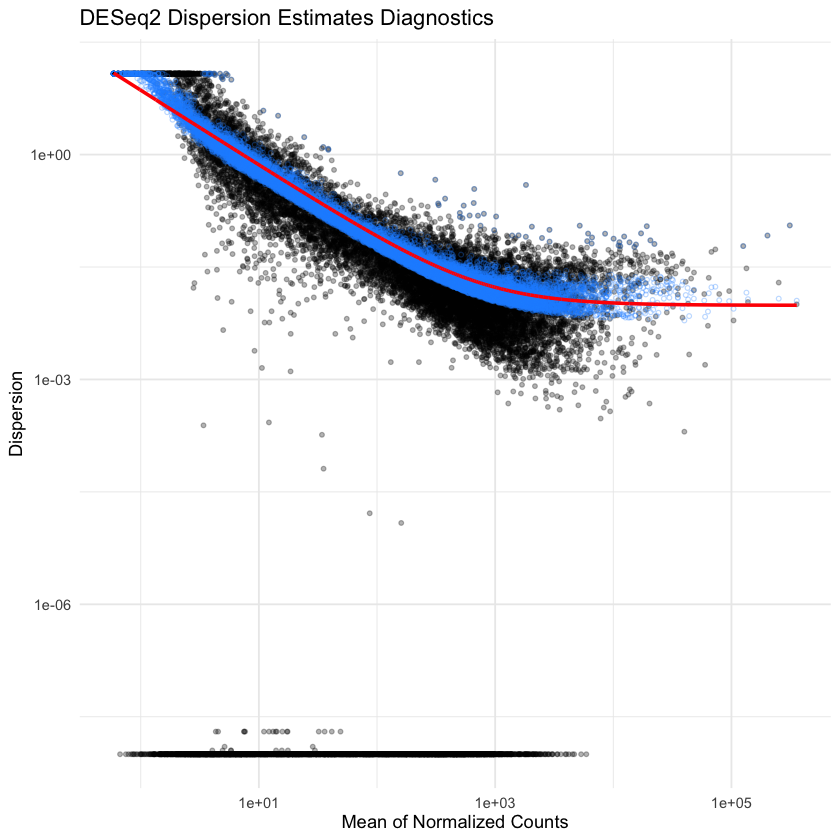

In [3]:
dds <- estimateSizeFactors(dds)
dds <- estimateDispersions(dds)

disp_df <- data.frame(
    baseMean    = mcols(dds)$baseMean,
    dispGeneEst = mcols(dds)$dispGeneEst,
    dispersion  = mcols(dds)$dispersion,
    dispFit     = mcols(dds)$dispFit
)
disp_df <- disp_df[disp_df$baseMean > 0, ]

dispersion_plot <- ggplot(disp_df, aes(x = baseMean)) +
    geom_point(aes(y = dispGeneEst), color = "black", alpha = 0.3, size = 1) +
    geom_point(aes(y = dispersion), color = "dodgerblue", alpha = 0.3, size = 1, shape = 1) +
    geom_line(aes(y = dispFit), color = "red", linewidth = 1) +
    scale_x_log10() + scale_y_log10() +
    theme_minimal() +
    labs(title = "DESeq2 Dispersion Estimates Diagnostics", x = "Mean of Normalized Counts", y = "Dispersion")

print(dispersion_plot)
ggsave("f_figures/Dispersion_Estimates.png", plot = dispersion_plot, width = 8, height = 6, dpi = 300)

## 4. Dimensionality Reduction & Diversity Testing
Performs Principal Component Analysis (PCA) to check sample clustering, followed by PERMANOVA and Beta Dispersion tests to quantify group differences.

using ntop=500 top features by variance



[1] "--- Multi-Factor PERMANOVA (Condition1 * Condition2) ---"
Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = dist_matrix ~ Condition1 * Condition2, data = sample_info, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)   
Model     3   2184.7 0.47189 2.3828  0.004 **
Residual  8   2445.0 0.52811                 
Total    11   4629.8 1.00000                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
[1] "--- 2 Categories (Fraction Only) ---"
Permutation test for adonis under reduced model
Permutation: free
Number of permutations: 999

adonis2(formula = dist_matrix ~ Condition2, data = sample_info, permutations = 999)
         Df SumOfSqs      R2      F Pr(>F)   
Model     1   1594.5 0.34441 5.2534  0.002 **
Residual 10   3035.2 0.65559                 
Total    11   4629.8 1.00000                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
[1] "--- Beta Dispers

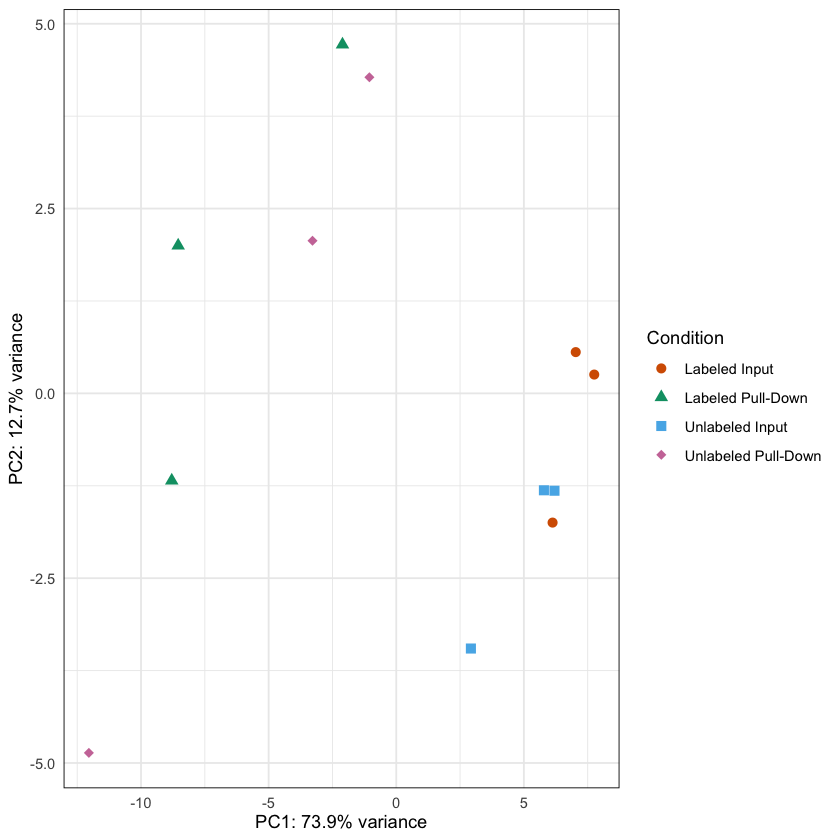

In [4]:
# PCA Plotting
pca_data <- plotPCA(vsd, intgroup = c("Condition1", "Condition2"), ntop = PCA_gene_count, returnData = TRUE)

group_colors <- c("lab:input" = "#D55E00", "lab:pull_down" = "#009E73", 
                  "unlab:input" = "#56B4E9", "unlab:pull_down" = "#CC79A7")
group_shapes <- c("lab:input" = 16, "lab:pull_down" = 17, 
                  "unlab:input" = 15, "unlab:pull_down" = 18)
group_labels <- c("lab:input" = "Labeled Input", "lab:pull_down" = "Labeled Pull-Down",
                  "unlab:input" = "Unlabeled Input", "unlab:pull_down" = "Unlabeled Pull-Down")

pca_figure <- ggplot(pca_data, aes(x = PC1, y = PC2, color = group, shape = group)) +
    geom_point(size = 2.5) +
    scale_color_manual(name = "Condition", values = group_colors, labels = group_labels) +
    scale_shape_manual(name = "Condition", values = group_shapes, labels = group_labels) +
    labs(x = glue("PC1: {round(attr(pca_data, 'percentVar')[1] * 100, 1)}% variance"),
         y = glue("PC2: {round(attr(pca_data, 'percentVar')[2] * 100, 1)}% variance")) +
    theme_minimal() +
    theme(panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5))

print(pca_figure)

# Beta Diversity and PERMANOVA
dist_matrix <- vegdist(t(assay(vsd)), method = "euclidean")

print("--- Multi-Factor PERMANOVA (Condition1 * Condition2) ---")
print(adonis2(dist_matrix ~ Condition1 * Condition2, data = sample_info, permutations = 999))

print("--- 2 Categories (Fraction Only) ---")
print(adonis2(dist_matrix ~ Condition2, data = sample_info, permutations = 999))

print("--- Beta Dispersion (Across 4 Conditions) ---")
combined_groups <- interaction(sample_info$Condition1, sample_info$Condition2)
print(anova(betadisper(dist_matrix, group = combined_groups)))

## 5. Differential Expression Analysis
Executes the DESeq model, extracts relevant contrasts using LFC shrinkage, and categorises genes into strict confidence tiers.

In [5]:
dds <- DESeq(dds, quiet = TRUE)
coef_names <- resultsNames(dds)

# Contrast 1: Labeled Pull-down vs Labeled Input
c1_list <- list(c("Condition2_pull_down_vs_input", "Condition1lab.Condition2pull_down"))
res_lab_PD_vs_Input <- results(dds, contrast = c1_list)
res_lab_PD_vs_Input_shrunk <- lfcShrink(dds, contrast = c1_list, type = "ashr", quiet = TRUE)

# Contrast 2: Labeled Pull-down vs All Input
all_inputs_contrast <- rep(0, length(coef_names))
all_inputs_contrast[which(coef_names == "Condition2_pull_down_vs_input")] <- 1
all_inputs_contrast[which(coef_names == "Condition1lab.Condition2pull_down")] <- 0.5
res_lab_PD_vs_All_Input <- results(dds, contrast = all_inputs_contrast)
res_lab_PD_vs_All_Input_shrunk <- lfcShrink(dds, contrast = all_inputs_contrast, type = "ashr", quiet = TRUE)

# Contrast 3: Labeled Pull-down vs Unlabeled Pull-down
c3_list <- list(c("Condition1_lab_vs_unlab", "Condition1lab.Condition2pull_down"))
res_lab_vs_unlab_PD <- results(dds, contrast = c3_list)
res_lab_vs_unlab_PD_shrunk <- lfcShrink(dds, contrast = c3_list, type = "ashr", quiet = TRUE)

# Helper Function: Categorise expression tiers cleanly
categorise_expression_tiers <- function(unshrunk_res, shrunk_res, fc_cut, padj_cut, pval_cut) {
    df <- data.frame(log2FoldChange = shrunk_res$log2FoldChange, 
                     padj = unshrunk_res$padj, pvalue = unshrunk_res$pvalue, row.names = rownames(shrunk_res))
    df <- df[!is.na(df$padj) & !is.na(df$pvalue), ]
    
    is_up_strong   <- df$log2FoldChange > fc_cut
    is_up_mod      <- df$log2FoldChange > 0 & df$log2FoldChange <= fc_cut
    is_down_strong <- df$log2FoldChange < -fc_cut
    is_down_mod    <- df$log2FoldChange >= -fc_cut & df$log2FoldChange < 0
    is_strong_stat <- df$padj < padj_cut
    is_weak_stat   <- df$padj >= padj_cut & df$pvalue < pval_cut

    df$Confidence_Tier <- "Not Significant"
    df$Confidence_Tier[is_up_strong & is_strong_stat]   <- "Tier 1: Strongly Up, Strong Stats"
    df$Confidence_Tier[is_up_mod & is_strong_stat]      <- "Tier 2: Moderately Up, Strong Stats"
    df$Confidence_Tier[is_up_strong & is_weak_stat]     <- "Tier 3: Strongly Up, Weak Stats"
    df$Confidence_Tier[is_up_mod & is_weak_stat]        <- "Tier 4: Moderately Up, Weak Stats"
    df$Confidence_Tier[is_down_strong & is_strong_stat] <- "Tier 1: Strongly Down, Strong Stats"
    df$Confidence_Tier[is_down_mod & is_strong_stat]    <- "Tier 2: Moderately Down, Strong Stats"
    df$Confidence_Tier[is_down_strong & is_weak_stat]   <- "Tier 3: Strongly Down, Weak Stats"
    df$Confidence_Tier[is_down_mod & is_weak_stat]      <- "Tier 4: Moderately Down, Weak Stats"
    return(df)
}

# Apply logic and export summaries
comparisons <- list(
    "Lab_PD_vs_Input"     = list(u = res_lab_PD_vs_Input, s = res_lab_PD_vs_Input_shrunk),
    "Lab_PD_vs_All_Input" = list(u = res_lab_PD_vs_All_Input, s = res_lab_PD_vs_All_Input_shrunk),
    "Lab_vs_Unlab_PD"     = list(u = res_lab_vs_unlab_PD, s = res_lab_vs_unlab_PD_shrunk)
)

tiered_results <- list()
for (comp_name in names(comparisons)) {
    message(glue("\n--- Categorising Comparison: {comp_name} ---"))
    df <- categorise_expression_tiers(comparisons[[comp_name]]$u, comparisons[[comp_name]]$s, 
                                      FC_thresh, FCPadj, FCPval)
    print(table(df$Confidence_Tier))
    tiered_results[[comp_name]] <- df
    write.csv(df, file = glue("o_outputs/processed_data/DE_results/Tiered_Results_{comp_name}.csv"))
}

# Assign primary analysis datasets for downstream tasks
categorised_PD_vs_Input <- tiered_results[["Lab_PD_vs_Input"]]
categorised_PD_vs_All_Input <- tiered_results[["Lab_PD_vs_All_Input"]]
categorised_lab_vs_unlab_PD <- tiered_results[["Lab_vs_Unlab_PD"]]

--- Categorising Comparison: Lab_PD_vs_Input ---




                      Not Significant   Tier 1: Strongly Down, Strong Stats 
                                 9371                                    13 
    Tier 1: Strongly Up, Strong Stats Tier 2: Moderately Down, Strong Stats 
                                    9                                   866 
  Tier 2: Moderately Up, Strong Stats   Tier 4: Moderately Down, Weak Stats 
                                  509                                   825 
    Tier 4: Moderately Up, Weak Stats 
                                  712 


--- Categorising Comparison: Lab_PD_vs_All_Input ---




                      Not Significant   Tier 1: Strongly Down, Strong Stats 
                                 9127                                    11 
    Tier 1: Strongly Up, Strong Stats Tier 2: Moderately Down, Strong Stats 
                                    3                                  1704 
  Tier 2: Moderately Up, Strong Stats   Tier 4: Moderately Down, Weak Stats 
                                 1282                                   732 
    Tier 4: Moderately Up, Weak Stats 
                                  755 


--- Categorising Comparison: Lab_vs_Unlab_PD ---




                    Not Significant   Tier 1: Strongly Up, Strong Stats 
                              16265                                   1 
Tier 4: Moderately Down, Weak Stats   Tier 4: Moderately Up, Weak Stats 
                                353                                 270 


## 6. Differential Expression Visualisation
Generates Volcano and MA plots to observe the distribution of fold changes and significance. 
*(Note: Ensure 'res' is defined as your target contrast prior to execution)*

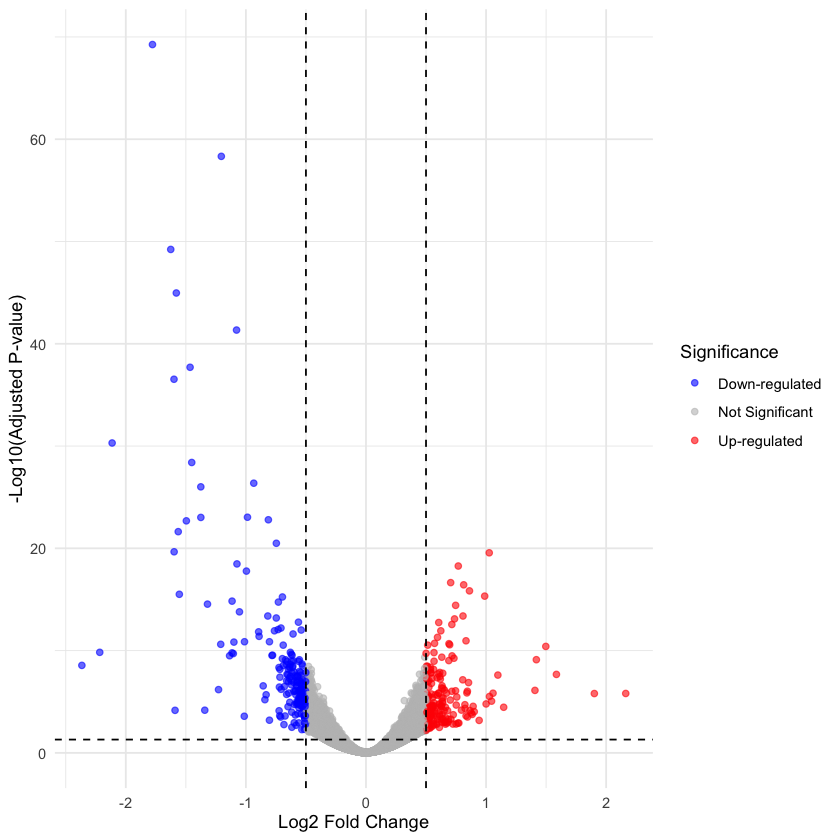

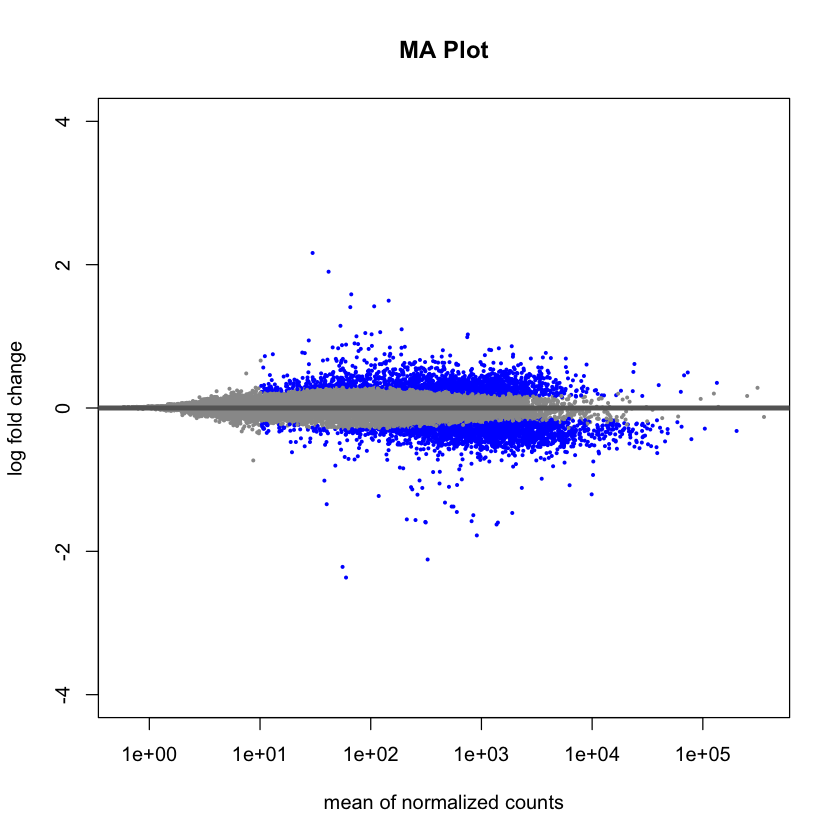

In [6]:
# Set primary 'res' for plotting (using Labeled PD vs All Input as default for visualisations)
res <- res_lab_PD_vs_All_Input_shrunk

# 1. Volcano Plot
res_df <- as.data.frame(res)[!is.na(res$padj), ]
res_df$Significance <- "Not Significant"
res_df$Significance[res_df$log2FoldChange > 0.5 & res_df$padj < 0.05] <- "Up-regulated"
res_df$Significance[res_df$log2FoldChange < -0.5 & res_df$padj < 0.05] <- "Down-regulated"

volcano_plot <- ggplot(res_df, aes(x = log2FoldChange, y = -log10(padj), color = Significance)) +
    geom_point(alpha = 0.6, size = 1.5) +
    scale_color_manual(values = c("Up-regulated" = "red", "Down-regulated" = "blue", "Not Significant" = "grey")) +
    geom_vline(xintercept = c(-0.5, 0.5), linetype = "dashed", color = "black") +
    geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "black") +
    theme_minimal() + labs(x = "Log2 Fold Change", y = "-Log10(Adjusted P-value)")

print(volcano_plot)
ggsave("f_figures/DE/Volcano_Plot.png", plot = volcano_plot, width = 8, height = 4, dpi = 300)

# 2. MA Plot
plotMA(res, main = "MA Plot", ylim = c(-4, 4))
png("f_figures/MA/MA_Plot.png", width = 2400, height = 1800, res = 300)
plotMA(res, main = "MA Plot", ylim = c(-4, 4))
invisible(dev.off())

## 7. Expressed Gene Overlap (Optional)
Evaluates the overlap of significantly expressed genes across different targeted analyses.

In [7]:
# files <- list(
#     "LP_vs_UP"  = "o_outputs/processed_data/DE_results/DESeq2_upreg-Results_lab_pull_down_vs_unlab_pull_down.csv",
#     "LP_vs_LI"  = "o_outputs/processed_data/DE_results/DESeq2_upreg-Results_lab_pull_down_vs_lab_input.csv"
# )
# gene_list <- lapply(files, function(f) { if (file.exists(f)) return(read.csv(f)$X) else return(character(0)) })
# all_unique_genes <- unique(unlist(gene_list))
# presence_matrix <- sapply(gene_list, function(g) all_unique_genes %in% g)
# overlap_df <- as.data.frame(presence_matrix)
# row.names(overlap_df) <- all_unique_genes
# pheatmap(as.matrix(overlap_df) + 0, cluster_rows = TRUE, cluster_cols = FALSE, show_rownames = FALSE)

## 8. Network Analysis (Gene Correlation)
Builds a co-expression network map of the most highly variable genes across all samples using Pearson correlation.

In [8]:
norm_counts <- assay(vsd)
gene_correlations <- cor(t(norm_counts), method = "pearson")
top_var_genes <- head(order(rowVars(norm_counts), decreasing = TRUE), network_size)

network_plot <- pheatmap(
    norm_counts[top_var_genes, ],
    annotation_col = sample_info,
    show_rownames = FALSE,
    main = glue("Co-expression of Top {network_size} Variable Genes"),
    filename = glue("f_figures/Network-coexpr/Top_{network_size}_Coexpression_Heatmap.png"),
    width = 8, height = 6, silent = FALSE
)

## 9. Gene Ontology (GO) Enrichment Analysis & Visualisation
Identifies enriched biological processes among target gene clusters and produces dotplot visualisations.

Cilium-related terms in High-Confidence Up Targets: 1

Found 9 unique cilia genes. Sample: Arhgap35, Bbs4, Ccdc88a, Dzip1, Gsk3b, Kctd17



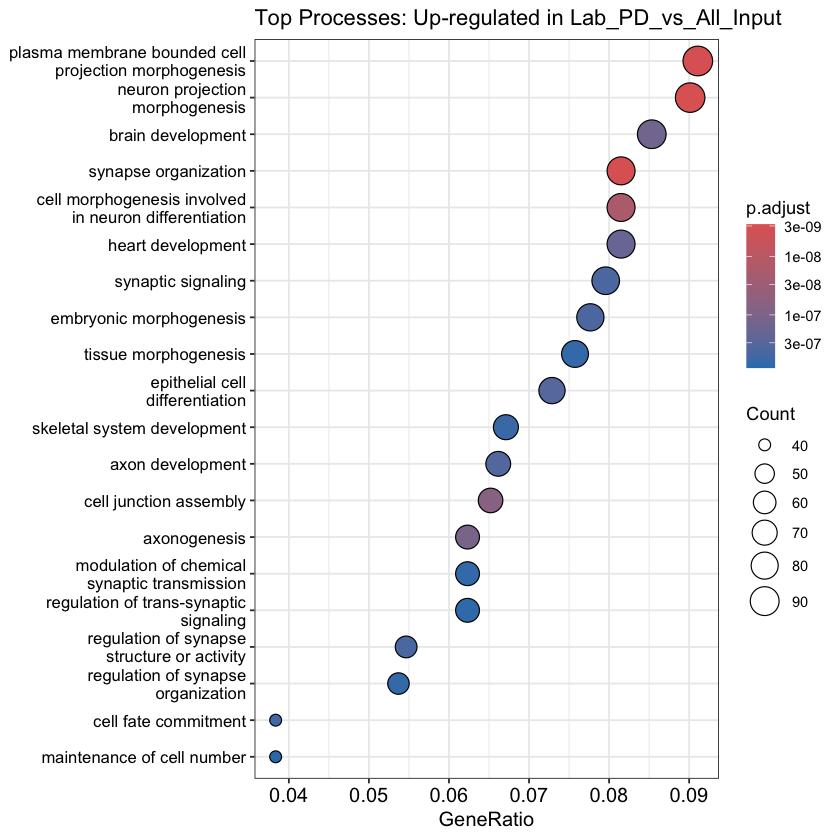

Cilium-related terms in Weak-Confidence Up Targets: 0



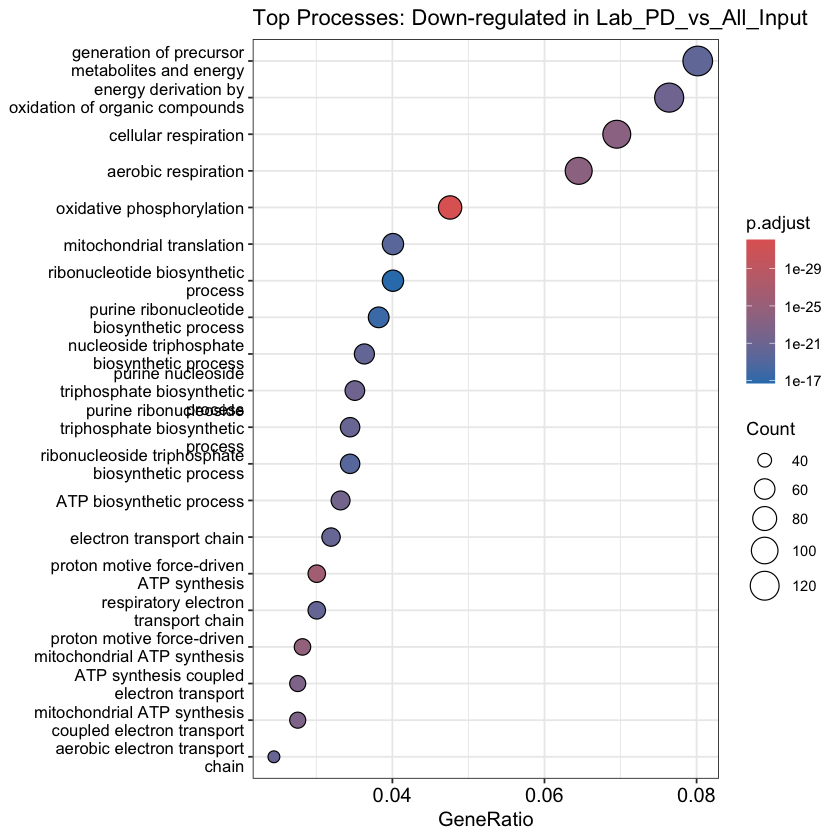

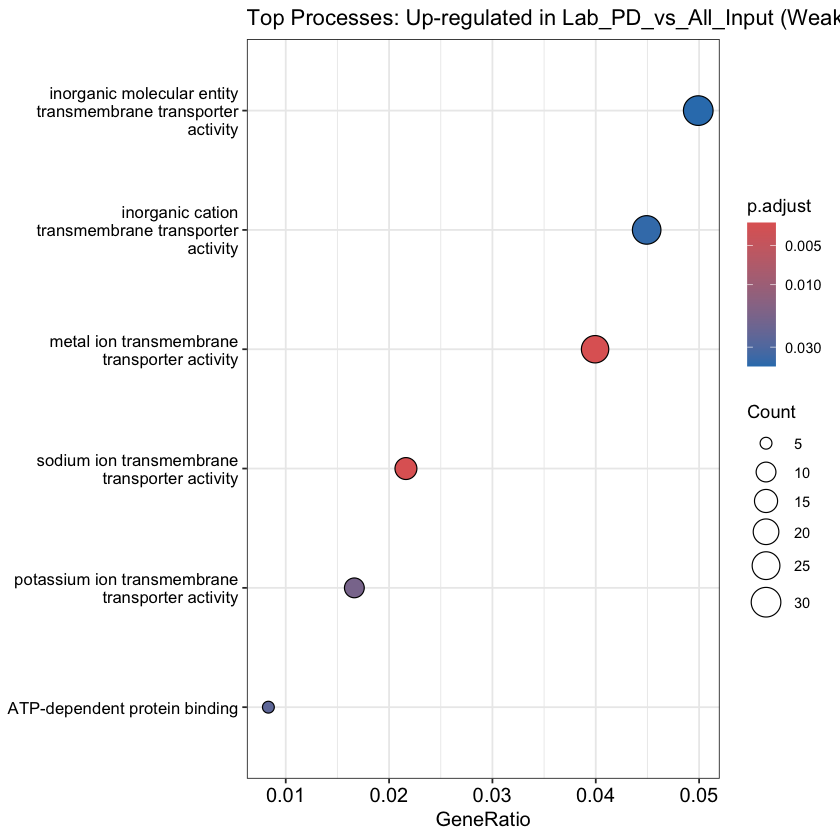

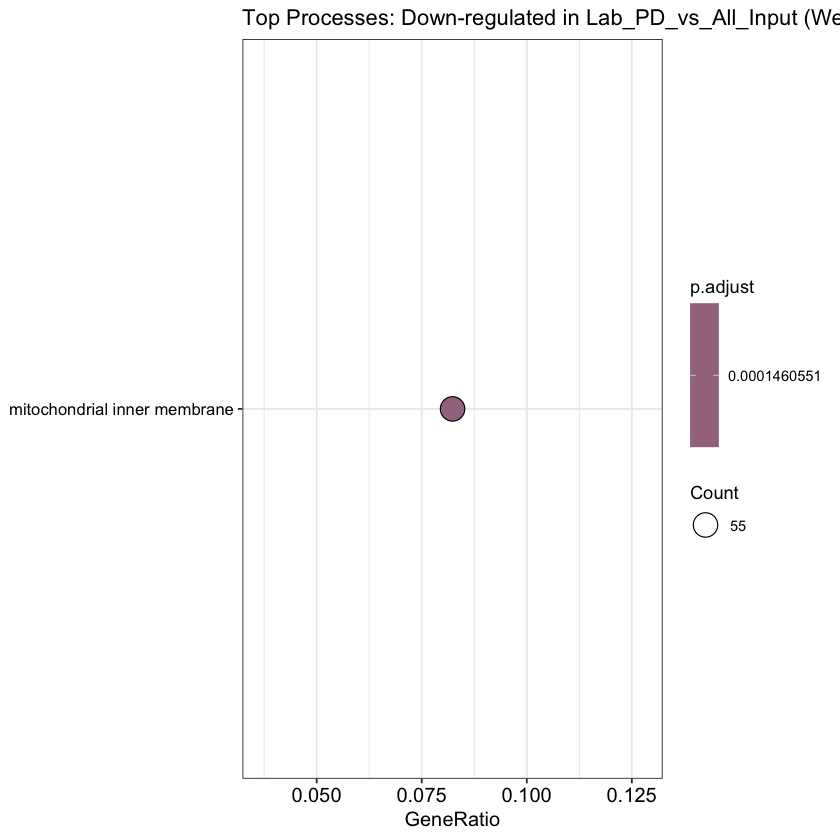

In [9]:
target_de_data <- categorised_PD_vs_All_Input
comparison_name <- "Lab_PD_vs_All_Input"

get_genes <- function(df, tiers) rownames(df[df$Confidence_Tier %in% tiers, ])
high_up   <- get_genes(target_de_data, c("Tier 1: Strongly Up, Strong Stats", "Tier 2: Moderately Up, Strong Stats"))
high_down <- get_genes(target_de_data, c("Tier 1: Strongly Down, Strong Stats", "Tier 2: Moderately Down, Strong Stats"))
weak_up   <- get_genes(target_de_data, c("Tier 3: Strongly Up, Weak Stats", "Tier 4: Moderately Up, Weak Stats"))
weak_down <- get_genes(target_de_data, c("Tier 3: Strongly Down, Weak Stats", "Tier 4: Moderately Down, Weak Stats"))

# Helper Functions for Enrichment and Reporting
run_go <- function(genes, universe) {
    if (length(genes) == 0) return(NULL)
    enrichGO(gene = genes, universe = universe, OrgDb = org.Mm.eg.db, keyType = "SYMBOL", 
             ont = "ALL", pAdjustMethod = "BH", pvalueCutoff = 0.05, qvalueCutoff = 0.2, readable = TRUE)
}

check_cilia <- function(go_res_df, label) {
    if (nrow(go_res_df) == 0) return(message(glue("No enriched GO terms for {label}.")))
    cilia <- go_res_df[grep("cili", go_res_df$Description, ignore.case = TRUE), ]
    message(glue("Cilium-related terms in {label}: {nrow(cilia)}"))
    if (nrow(cilia) > 0) {
        genes <- sort(unique(unlist(strsplit(paste(cilia$geneID, collapse = "/"), "/"))))
        message(glue("Found {length(genes)} unique cilia genes. Sample: "), paste(head(genes), collapse=", "))
    }
}

plot_go <- function(go_obj, title, filename) {
    if(is.null(go_obj) || nrow(go_obj) == 0) return()
    p <- dotplot(go_obj, showCategory = 20) + ggtitle(title) + theme(axis.text.y = element_text(size = 10), axis.title.y = element_blank())
    print(p)
    ggsave(filename, plot = p, width = 10, height = 8, dpi = 300)
}

# Execute and Export (High Confidence)
universe <- rownames(target_de_data)
go_high_up   <- run_go(high_up, universe)
go_high_down <- run_go(high_down, universe)
go_weak_up   <- run_go(weak_up, universe)
go_weak_down <- run_go(weak_down, universe)

if(!is.null(go_high_up)) write.csv(as.data.frame(go_high_up), "o_outputs/processed_data/GO_results/GO_HighConf_UP.csv")
if(!is.null(go_high_down)) write.csv(as.data.frame(go_high_down), "o_outputs/processed_data/GO_results/GO_HighConf_DOWN.csv")
if(!is.null(go_weak_up)) write.csv(as.data.frame(go_weak_up), "o_outputs/processed_data/GO_results/GO_WeakConf_UP.csv")
if(!is.null(go_weak_down)) write.csv(as.data.frame(go_weak_down), "o_outputs/processed_data/GO_results/GO_WeakConf_DOWN.csv")

check_cilia(if(!is.null(go_high_up)) as.data.frame(go_high_up) else data.frame(), "High-Confidence Up Targets")
plot_go(go_high_up, glue("Top Processes: Up-regulated in {comparison_name}"), glue("f_figures/GO/GO_UP_{comparison_name}.png"))
plot_go(go_high_down, glue("Top Processes: Down-regulated in {comparison_name}"), glue("f_figures/GO/GO_DOWN_{comparison_name}.png"))

check_cilia(if(!is.null(go_weak_up)) as.data.frame(go_weak_up) else data.frame(), "Weak-Confidence Up Targets")
plot_go(go_weak_up, glue("Top Processes: Up-regulated in {comparison_name} (Weak Confidence)"), glue("f_figures/GO/GO_Weak_UP_{comparison_name}.png"))
plot_go(go_weak_down, glue("Top Processes: Down-regulated in {comparison_name} (Weak Confidence)"), glue("f_figures/GO/GO_Weak_DOWN_{comparison_name}.png"))

## 10. Gene Set Enrichment Analysis (GSEA)
Generates a ranked metric for all genes passing the threshold to evaluate broader pathway activation/suppression, outputting global visualisations and targeted running scores.

using 'fgsea' for GSEA analysis, please cite Korotkevich et al (2019).


preparing geneSet collections...

GSEA analysis...

Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
"There are ties in the preranked stats (0.46% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results."
leading edge analysis...

done...

GSEA Cilia pathways identified: 3



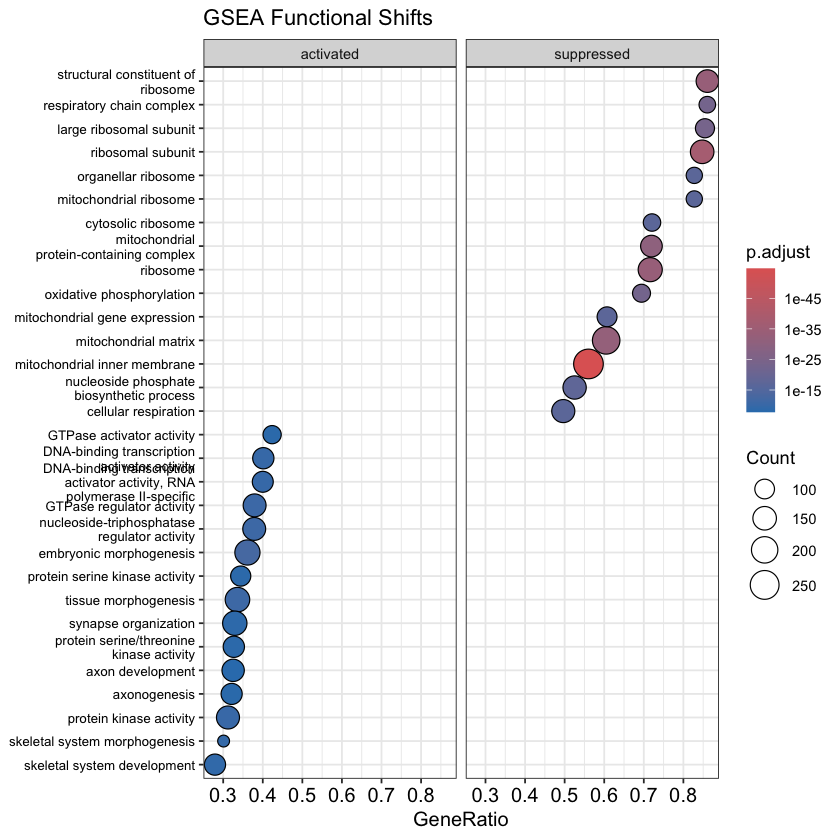

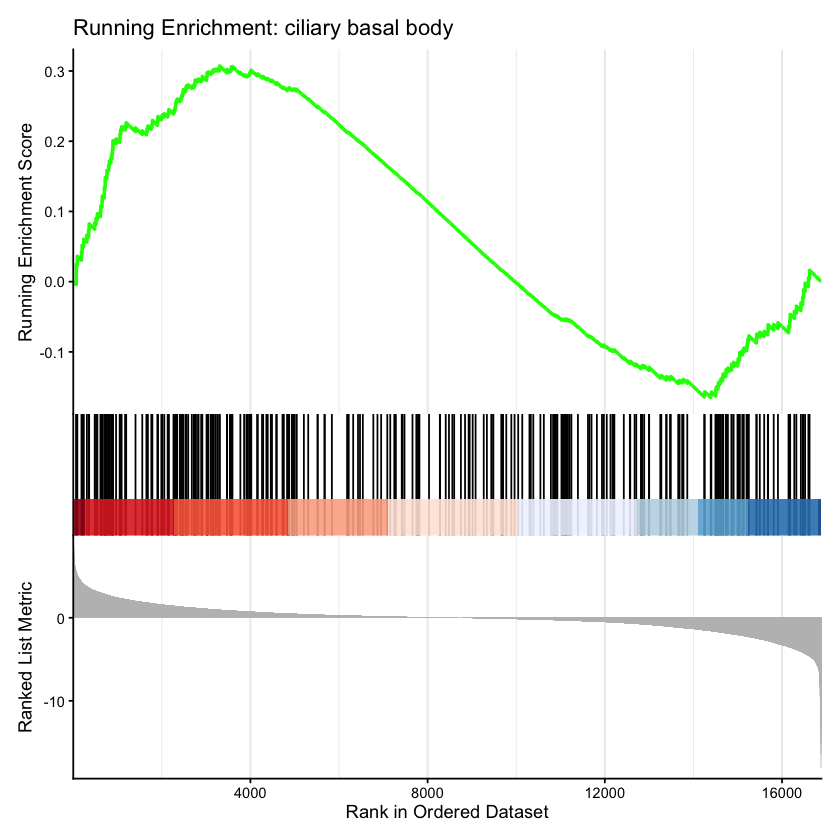

In [10]:
# res <- res_lab_PD_vs_Input_shrunk
res <- res_lab_PD_vs_All_Input_shrunk
# res <- res_lab_vs_unlab_PD_shrunk

res_df <- as.data.frame(res)
res_df <- res_df[!is.na(res_df$pvalue) & !is.na(res_df$log2FoldChange), ]

# Calculate ranking statistic and sort
# ranked_genes <- sign(res_df$log2FoldChange) * (-log10(res_df$pvalue))
ranked_genes <- res_df$log2FoldChange / res_df$lfcSE
names(ranked_genes) <- rownames(res_df)
ranked_genes <- ranked_genes[!is.na(ranked_genes)]
ranked_genes <- sort(ranked_genes, decreasing = TRUE)

# Execute GSEA
gsea_go <- gseGO(geneList = ranked_genes, OrgDb = org.Mm.eg.db, keyType = "SYMBOL", 
                 ont = "ALL", pvalueCutoff = 0.1, pAdjustMethod = "BH", eps = 0, seed = 123)

if (!is.null(gsea_go) && nrow(gsea_go) > 0) {
    gsea_results <- as.data.frame(gsea_go)
    write.csv(gsea_results, "o_outputs/processed_data/GO_results/GSEA_GO_Enrichment.csv")
    
    cilia_terms <- gsea_results[grep("cili", gsea_results$Description, ignore.case = TRUE), ]
    message(glue("GSEA Cilia pathways identified: {nrow(cilia_terms)}"))
    
    # GSEA Global Dotplot
    dot_gsea <- dotplot(gsea_go, showCategory = 15, split = ".sign") + facet_grid(. ~ .sign) +
        ggtitle("GSEA Functional Shifts") + theme(axis.text.y = element_text(size = 8))
    print(dot_gsea)
    ggsave("f_figures/GO/GSEA_Dotplot.png", plot = dot_gsea, width = 11, height = 8, dpi = 300)
    
    # GSEA Specific Mountain Plot
    if (nrow(cilia_terms) > 0) {
        gsea_mountain <- gseaplot2(gsea_go, geneSetID = cilia_terms$ID[1], 
                                   title = glue("Running Enrichment: {cilia_terms$Description[1]}"))
        print(gsea_mountain)
        ggsave("f_figures/GO/GSEA_Mountain_Plot_Cilia.png", plot = gsea_mountain, width = 8, height = 6, dpi = 300)
    }
}

## 11. Deep-Dive: Ciliary Basal Body Bi-directional Drivers
Extracts the "leading edge" genes from our GSEA mountain plot to identify the specific drivers of the bi-directional pathway shift. Visualises their targeted expression and builds an exclusive co-expression network to search for anti-correlated structural modules. Exports lists for downstream transcription factor/motif analysis.

In [11]:
# Ensure cilia_terms is available from Section 10
if (exists("cilia_terms") && nrow(cilia_terms) > 0) {
    
    # 1. Isolate the Core Drivers
    # Target the top cilia term (which generated our mountain plot)
    target_term_id <- cilia_terms$ID[1]
    target_term_desc <- cilia_terms$Description[1]
    safe_name <- gsub(" ", "_", target_term_desc) # For clean filenames
    
    message(glue("\n--- Analysing Core Drivers for: {target_term_desc} ({target_term_id}) ---"))
    
    # Extract the leading edge string and split into individual genes
    core_genes_str <- cilia_terms$core_enrichment[1]
    core_genes <- unlist(strsplit(core_genes_str, "/"))
    
    # Determine which are up-regulated vs down-regulated using our shrunken LFCs
    core_genes_lfc <- res_df[core_genes, "log2FoldChange"]
    names(core_genes_lfc) <- core_genes
    
    up_drivers <- names(core_genes_lfc[core_genes_lfc > 0])
    down_drivers <- names(core_genes_lfc[core_genes_lfc < 0])
    
    message(glue("Total Leading Edge Genes: {length(core_genes)}"))
    message(glue("Up-regulated Drivers: {length(up_drivers)}"))
    message(glue("Down-regulated Drivers: {length(down_drivers)}"))
    
    # Export these strictly separated lists for downstream TF/Motif analysis (e.g., ChEA3)
    write.table(up_drivers, glue("o_outputs/processed_data/GO_results/{safe_name}_Up_Drivers.txt"), 
                row.names = FALSE, col.names = FALSE, quote = FALSE)
    write.table(down_drivers, glue("o_outputs/processed_data/GO_results/{safe_name}_Down_Drivers.txt"), 
                row.names = FALSE, col.names = FALSE, quote = FALSE)
    
    # 2. Visualise the Specific Pathway (Targeted Heatmap)
    # Subset our normalised count matrix for just these core genes
    norm_counts <- assay(vsd)
    core_counts <- norm_counts[core_genes, ]
    
    # Draw heatmap scaling by row (Z-score) to clearly see relative up/down shifts
    pheatmap(core_counts,
             annotation_col = sample_info,
             scale = "row",
             show_rownames = TRUE,
             fontsize_row = 6,
             main = glue("Expression of {target_term_desc} Leading Edge Drivers"),
             filename = glue("f_figures/GO/{safe_name}_Expression_Heatmap.png"),
             width = 8, height = 10, silent = FALSE)
    
    # 3. Targeted Network Analysis (Co-expression Module)
    # Run Pearson correlation strictly on the basal body genes
    core_correlations <- cor(t(core_counts), method = "pearson")
    
    pheatmap(core_correlations,
             show_rownames = TRUE,
             show_colnames = TRUE,
             fontsize_row = 6,
             fontsize_col = 6,
             main = glue("Co-expression Network: {target_term_desc}"),
             filename = glue("f_figures/Network-coexpr/{safe_name}_Coexpression_Heatmap.png"),
             width = 10, height = 10, silent = FALSE)
             
    message(glue("Analysis complete. Targeted heatmaps and separated driver lists have been exported."))
    
} else {
    message("No cilia terms found in GSEA results to analyse.")
}

--- Analysing Core Drivers for: ciliary basal body (GO:0036064) ---

Total Leading Edge Genes: 94

Up-regulated Drivers: 94

Down-regulated Drivers: 0

Analysis complete. Targeted heatmaps and separated driver lists have been exported.

